In [2]:
using Distributions
using MLUtils: DataLoader
using LinearAlgebra
using AbstractGPs
using CSV
using DataFrames
import ComponentArrays: ComponentArray
using DataInterpolations
using Revise
using CairoMakie
using ColorSchemes
using Flux.Functors: destructure
include("src/rgp.jl")
include("src/battModel.jl")
using .RecursiveGPs
using .battModel

In [1]:
using AbstractGPs
using Functors

In [ ]:
kernel = LinearKernel() + 0.3 * with_lengthscale(SEKernel(), 2)
params, kernelc = destructure(kernel)

UndefVarError: UndefVarError: `destructure` not defined in `Functors`
Suggestion: check for spelling errors or missing imports.

# Sin(X)

In [381]:
σ_r = 0.5
l_r = 0.8
σ = 0.28

kernel = σ_r * with_lengthscale(SEKernel(), l_r)
N_basis = 50
limit_basis = [-10,10]
X_basis = collect(range(limit_basis[1], limit_basis[2], length=n_basis))
rgp = RGPModel_HYP(kernel, σ, X_basis);


N_points = 200
limit_train = [-10,10]
X_train = collect(range(limit_basis[1], limit_basis[2], length=N_points))
f(x) = x./2 .+ (25 .* x ./ (1 .+ x.^2)) .* cos.(x) .+ rand(Normal(0, 0.1), size(x))
Y_train = f(X_train)

batch_size = 1
data = DataLoader((
    x=X_train, 
    y=Y_train
    ),
    batchsize=batch_size, shuffle=false
    )

200-element DataLoader(::@NamedTuple{x::Vector{Float64}, y::Vector{Float64}})
  with first element:
  (; x = 1-element Vector{Float64}, y = 1-element Vector{Float64})

In [382]:
animation = DataFrame(step=Int[], μ=Vector{Float64}[], σ=Vector{Float64}[])
ani_step = 2
param_evo = DataFrame(σ = Float64[], l = Float64[], σ_k = Float64[])

for (n,batch) in enumerate(data)
    learn!(rgp, batch.x, batch.y)
    push!(param_evo, (σ = rgp.μ_z[end], l = rgp.params[1], σ_k = rgp.params[2]))
    if n%ani_step == 0
        μ, Σ = predict(rgp,X_train)
        σ = sqrt.(abs.(diag(Σ)));
        push!(animation, (step=n, μ=μ, σ=σ))
    end
end

In [383]:
N_points = 400
limit_test= [-10,10]
X_test = collect(range(limit_test[1], limit_test[2], length=N_points))
Y_test= f(X_test)

μ, Σ = predict(rgp, X_test);
var_sin = sqrt.(diag(Σ));

In [384]:
fig = Figure(size = (1200, 600))
ax1 = Axis(fig[1, 1], title="GP updated for ocv", xlabel="soc", ylabel="ocv", xticks=limit_train[1]:1:limit_train[2])

# Static elements
lines!(ax1, X_train, Y_train, label="Real", color=:black)
ax1.title = "GP updated for sin(x)"
axislegend(ax1)

# Dynamic elements initialized with first frame
gp_line = lines!(ax1, X_train, animation.μ[1], label="OCV approx", color=:blue)

band_plot = band!(ax1, X_train, animation.μ[1] - 2*animation.σ[1], animation.μ[1] + 2*animation.σ[1]; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))
# Animate and save
record(fig, "pictures/animations/sin(x).mp4", 1:length(animation.μ); framerate=7) do i
    ax1.title = "GP updated for ocv — Frame $(i*ani_step) / $(N_points)"
    gp_line[2] = animation.μ[i]
    band_plot[2] = animation.μ[i] .- 2*animation.σ[i]
    band_plot[3] = animation.μ[i] .+ 2*animation.σ[i]
end

"pictures/animations/sin(x).mp4"

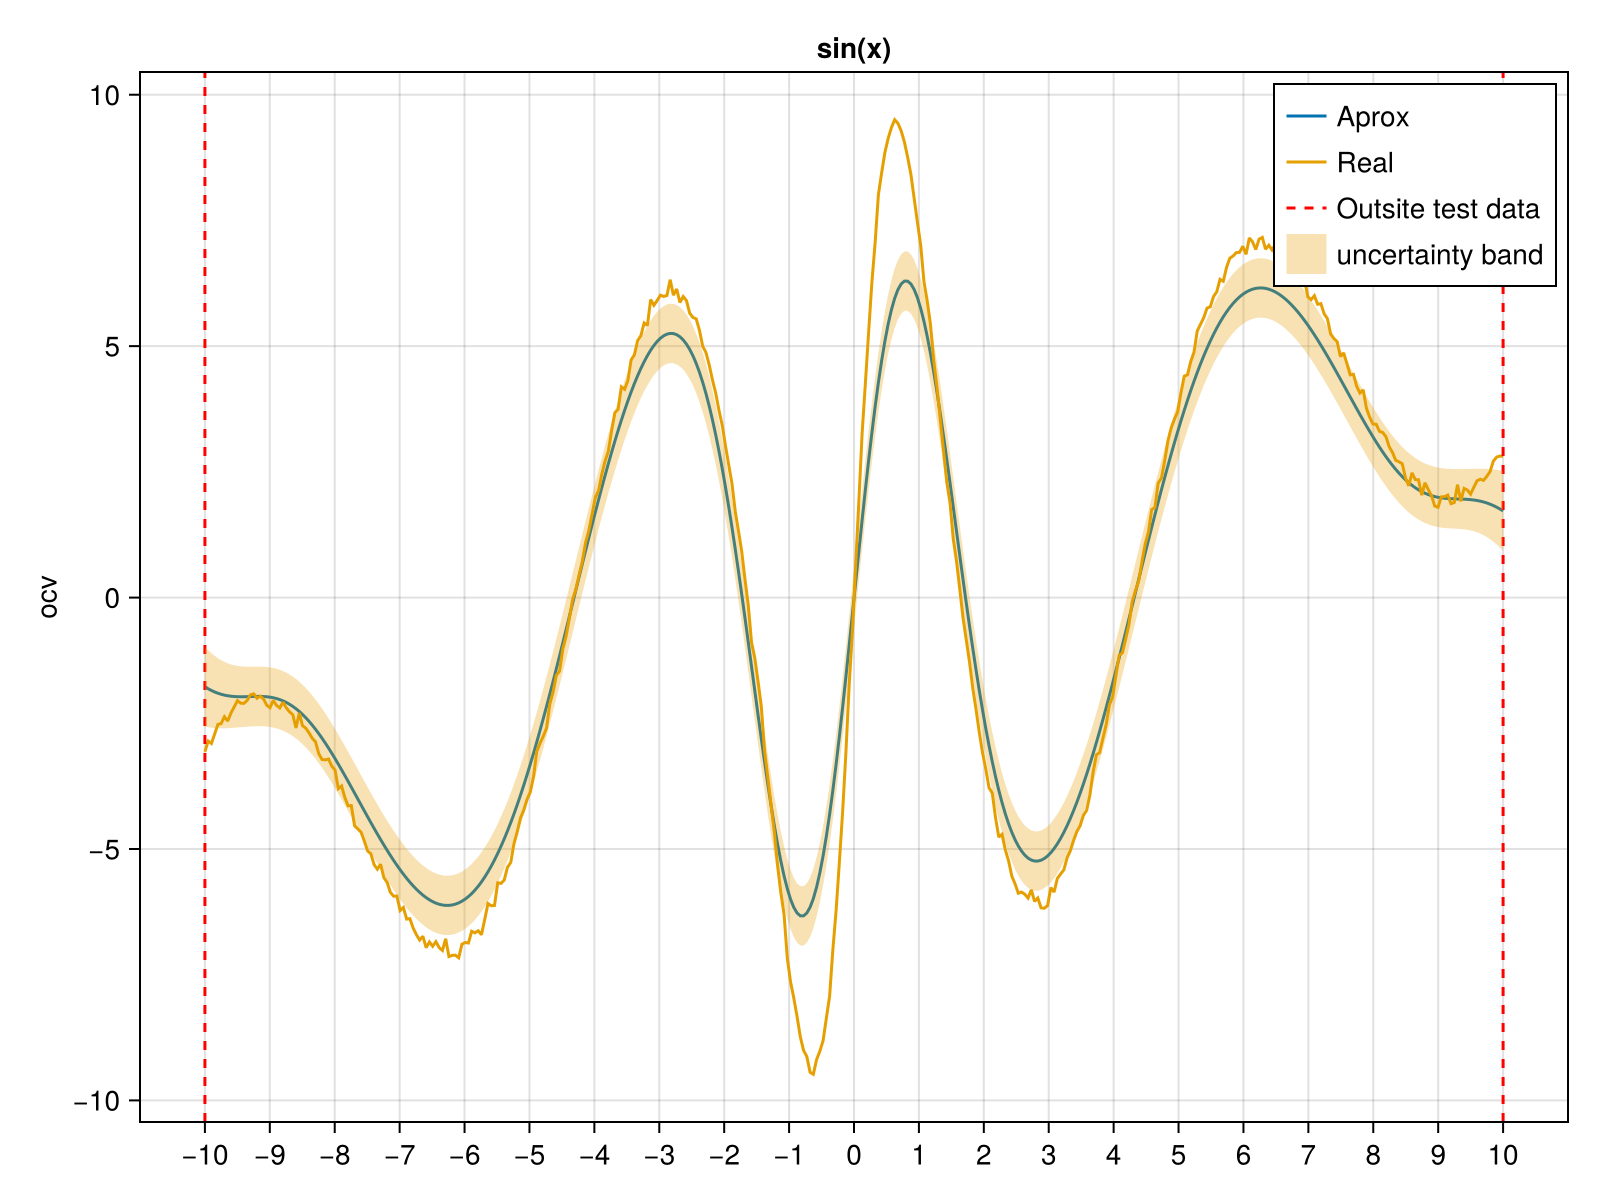

CairoMakie.Screen{IMAGE}


In [385]:
##  function
fig = Figure(size = (800, 600))
ax1 = Axis(fig[1, 1], title="sin(x)", ylabel="ocv", xticks=limit_test[1]:1:limit_test[2])
lines!(ax1, X_test, μ, label="Aprox")
lines!(ax1, X_test, Y_test, label="Real")

vlines!(ax1, [minimum(X_train), maximum(X_train) ], color=:red, linestyle=:dash, label="Outsite test data")
band!(ax1, X_test, μ - 2var_sin, μ + 2var_sin; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))
axislegend(ax1)

display(fig)

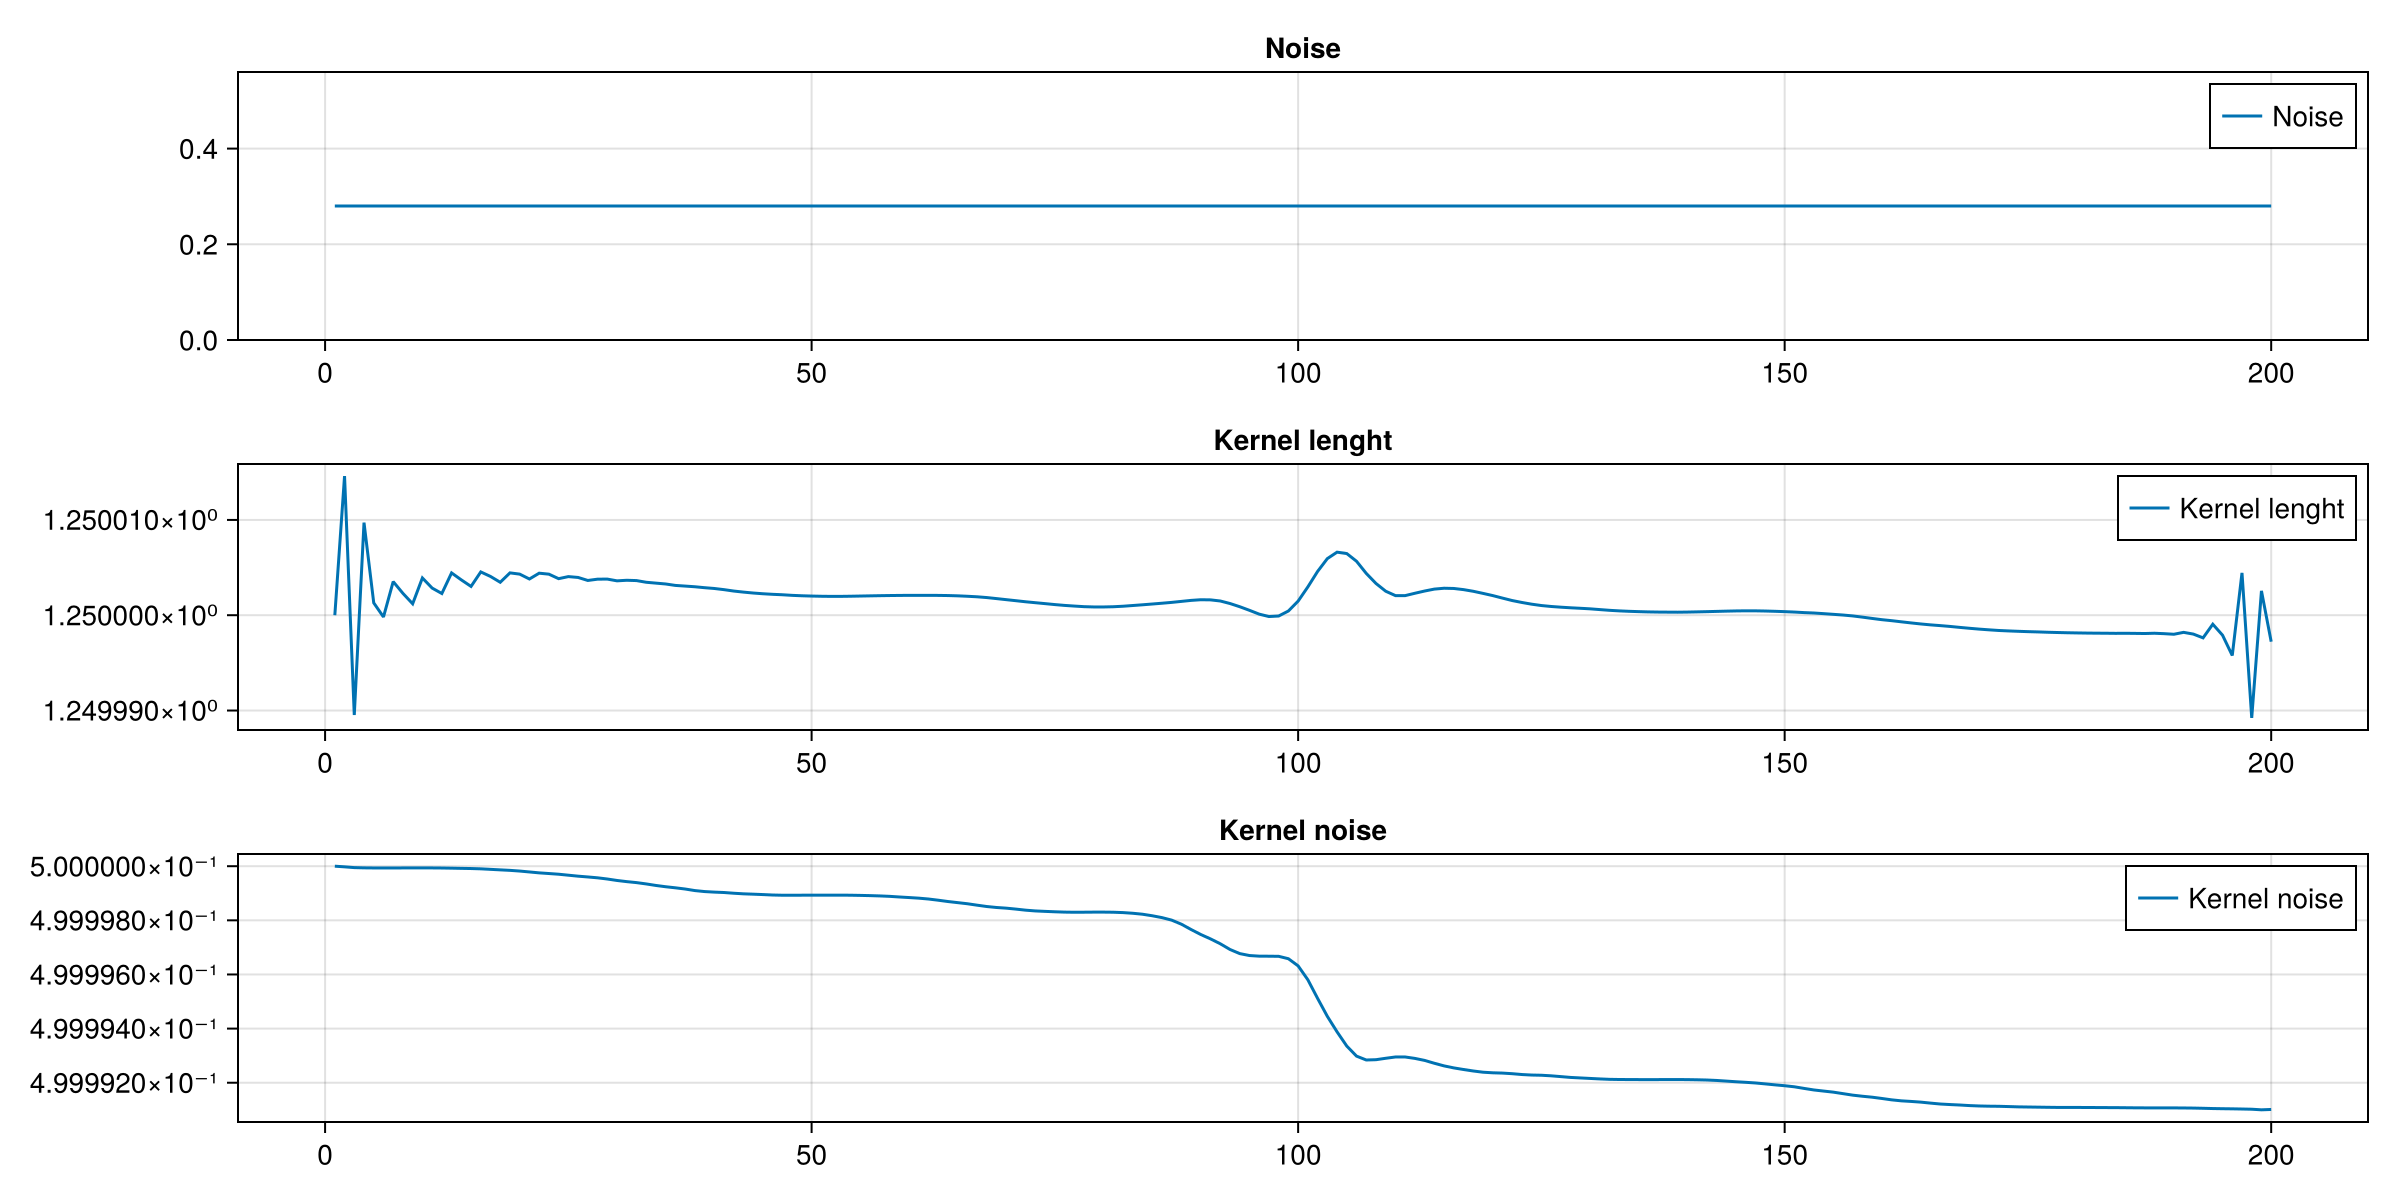

CairoMakie.Screen{IMAGE}


In [386]:
##  function
fig = Figure(size = (1200, 600))
ax1 = Axis(fig[1, 1], title="Noise")
ax2 = Axis(fig[2, 1], title="Kernel lenght")
ax3 = Axis(fig[3, 1], title="Kernel noise")
lines!(ax1, param_evo.σ, label="Noise")
lines!(ax2, param_evo.l, label="Kernel lenght")
lines!(ax3, param_evo.σ_k, label="Kernel noise")
axislegend(ax1)
axislegend(ax2)
axislegend(ax3)


display(fig)

# Profile 2

In [11]:
df_p2 = CSV.read("data/profile2.csv", DataFrame);

In [12]:
## Train
N_points = size(df_p2)[1]
soc_test = df_p2[!, "soc"][1:N_points]
i_test = df_p2[!, "i"][1:N_points]

v_test = df_p2[!, "v"][1:N_points];
batch_size = 1
data = DataLoader((
    x=(
    soc = soc_test,
    i = i_test
    ), 
    y=v_test
    ),
    batchsize=batch_size, shuffle=false
    );

In [ ]:
l_ocv = 0.5
σ_ocv = 0.5

l_r = 1.0
σ_r = 1.0

σ_f1 = 0.
σ_f2 = 0.


limit_basis_ocv = [0, 1]
step_basis_ocv = 0.01
X_basis_ocv = collect(limit_basis_ocv[1]:step_basis_ocv:limit_basis_ocv[2])
n_basis = size(X_basis_ocv)[1]
X_basis_r = collect(limit_basis_ocv[1]:step_basis_ocv:limit_basis_ocv[2])

gp_ocv = gp_ocv = GP(
    LinearKernel() +
    σ_ocv * with_lengthscale(SEKernel(), l_ocv)
)
rgp_ocv = RGPModel(gp_ocv, σ_f1, X_basis_ocv);

gp_r = GP(σ_r * with_lengthscale(SEKernel(), l_r))
rgp_r = RGPModel(gp_r, σ_f2, X_basis_r)

batt = BATTModel(rgp_ocv, rgp_r);


In [ ]:
for (n, batch) in enumerate(data)
    battery_learn!(batt, batch)
    println(rgp_ocv.μ)
end

[1.848054881085386e-5, 1.9164128967776425e-5, 1.984728152795345e-5, 2.052982057975644e-5, 2.12115424654469e-5, 2.1892282399717763e-5, 2.2571861231363383e-5, 2.325005586642956e-5, 2.3926698139397798e-5, 2.460154890030962e-5, 2.5274449279227952e-5, 2.59451778723043e-5, 2.6613517500954484e-5, 2.727931690071712e-5, 2.7942324245840895e-5, 2.8602360385120158e-5, 2.9259187858702155e-5, 2.991262836043409e-5, 3.056249513363463e-5, 3.120855240855671e-5, 3.1850569485770425e-5, 3.248839510081442e-5, 3.3121810384998774e-5, 3.3750626891536424e-5, 3.437460040015175e-5, 3.4993550914586264e-5, 3.5607316184691446e-5, 3.6215665511037404e-5, 3.681838678535707e-5, 3.7415371840884784e-5, 3.800635448597064e-5, 3.8591164019937576e-5, 3.9169632277267093e-5, 3.974159869791639e-5, 4.0306850328565546e-5, 4.0865257876127484e-5, 4.1416655710242266e-5, 4.196092383340423e-5, 4.2497745350792076e-5, 4.302711265693008e-5, 4.354882885450263e-5, 4.406281366348831e-5, 4.4568901453527206e-5, 4.506688687677509e-5, 4.55567538

Excessive output truncated after 524305 bytes.

, -5.116466740386219e13, -5.434883004594642e13, -5.7331301320389336e13, -6.0228610001755234e13, -6.290441757804034e13, -6.548308302774149e13, -6.7917549891999734e13, -7.016171764526647e13, -7.231420740974378e13, -7.428344940485008e13, -7.615873000697889e13, -7.788397504900031e13, -7.946261144662062e13, -8.096224182669677e13, -8.234562662336555e13, -8.354102405837005e13]
[5.749459870548805e14, 5.74045222015889e14, 5.728242659858339e14, 5.712987268109239e14, 5.69421594900463e14, 5.672446793400832e14, 5.647205093072502e14, 5.6189546739333025e14, 5.587691178708986e14, 5.552913408237826e14, 5.514856317297254e14, 5.473673264521304e14, 5.429361813150381e14, 5.382247604861874e14, 5.3318287180305794e14, 5.278478568306331e14, 5.22213861478962e14, 5.1629437331636725e14, 5.100586244396292e14, 5.035559955757546e14, 4.967874093928879e14, 4.897301862753388e14, 4.8240407103574956e14, 4.748622175803068e14, 4.6703176429427694e14, 4.5900138157658506e14, 4.507093878302375e14, 4.422092534756955e14, 4.33490

In [6]:
limit_predict = [0, 1]
step_predict = 0.01

X_predict_soc = collect(limit_predict[1]:step_predict:limit_predict[2])
rgp_ocv = batt.rgp_ocv
rgp_r = batt.rgp_r

μ_ocv = predict(rgp_ocv, X_predict_soc).μ
Σ_ocv = predict(rgp_ocv, X_predict_soc).Σ
var_ocv = sqrt.(abs.(diag(Σ_ocv)));
μ_r = predict(rgp_r, X_predict_soc).μ;
Σ_r = predict(rgp_r, X_predict_soc).Σ;
var_r = sqrt.(abs.(diag(Σ_r)));

V_p = predict(rgp_ocv, soc_test[1:50:end]).μ +  i_test[1:50:end].* predict(rgp_r, soc_test[1:50:end]).μ
V_r = v_test[1:50:end];

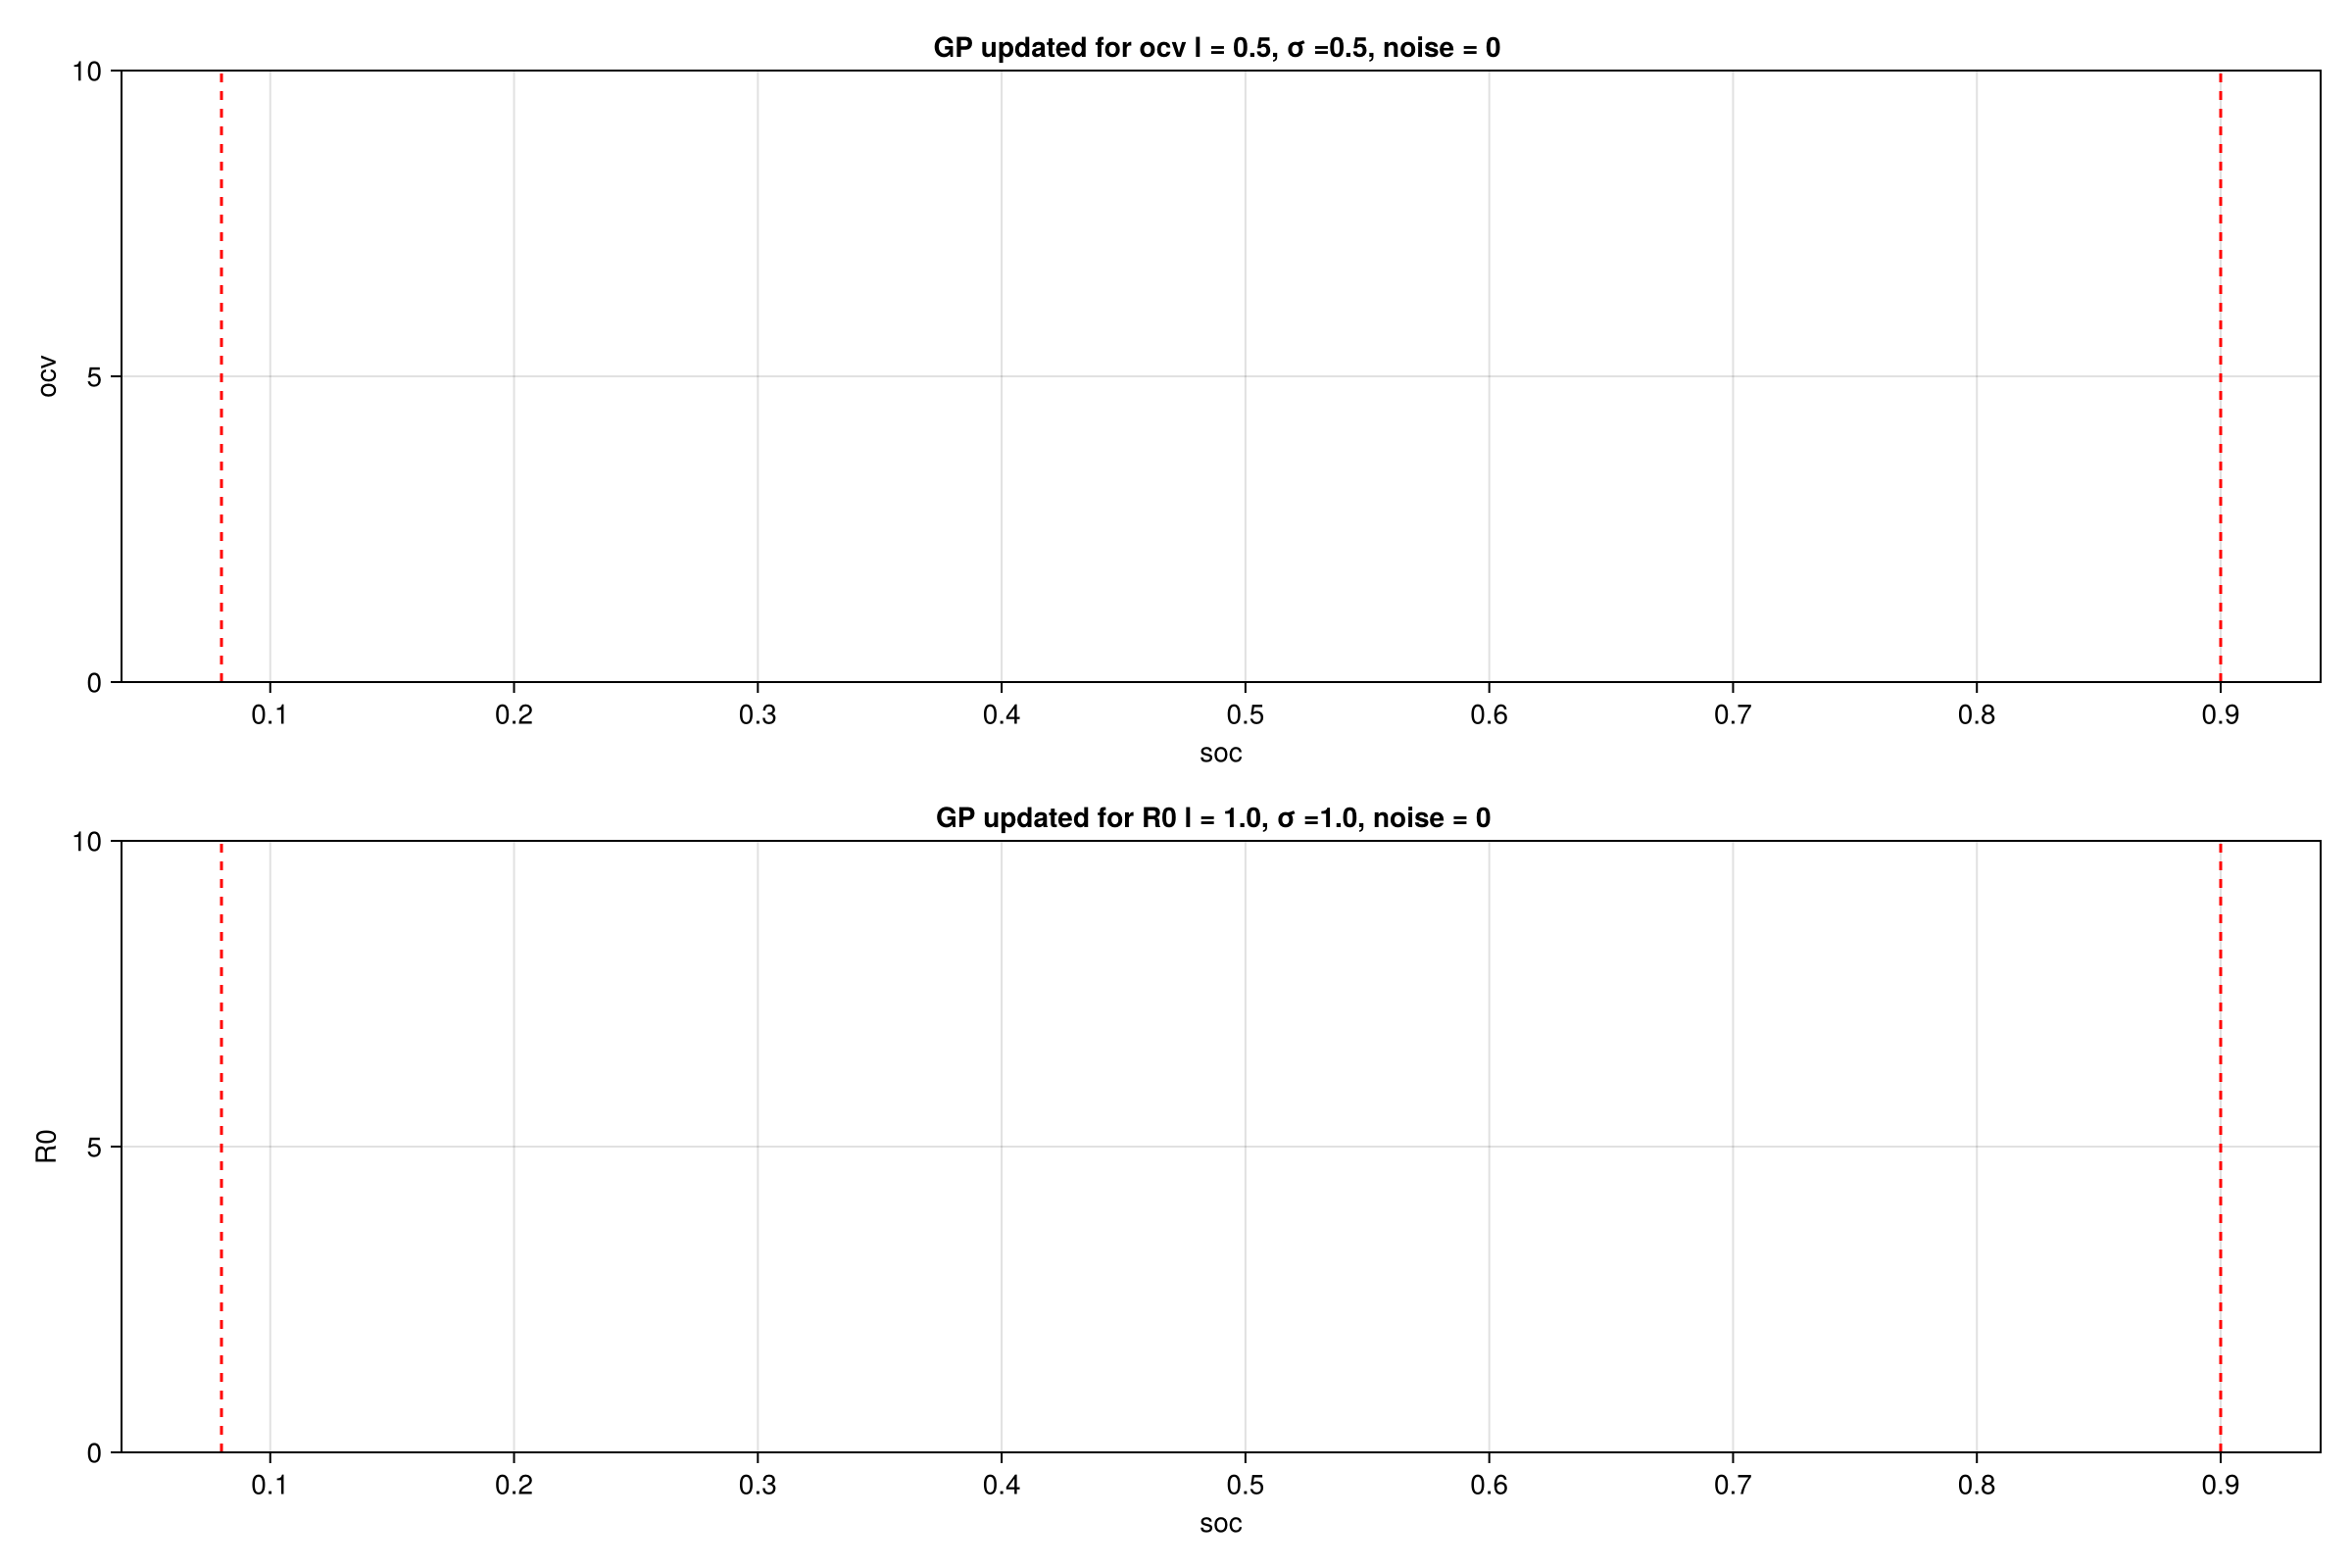

CairoMakie.Screen{IMAGE}


In [ ]:
##  function
fig = Figure(size = (1200, 800))
ax1 = Axis(fig[1, 1], title="GP updated for ocv l = $(l_ocv), σ =$(σ_ocv), noise = $(σ_f1) ", xlabel="soc", ylabel="ocv", xticks=limit_predict[1]:0.1:limit_predict[2])
lines!(ax1, X_predict_soc, μ_ocv, label="OCV aprox")
vlines!(ax1, [minimum(soc_test), maximum(soc_test) ], color=:red, linestyle=:dash, label="Outsite test data")
ylims!(ax1, 3.2, 4.2)
band!(ax1, X_predict_soc, μ_ocv - 2var_ocv, μ_ocv + 2var_ocv; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))

ax2 = Axis(fig[2, 1], title="GP updated for R0 l = $(l_r), σ =$(σ_r), noise = $(σ_f2)  ", xlabel="soc", ylabel="R0", xticks=limit_predict[1]:0.1:limit_predict[2])
lines!(ax2, X_predict_soc, μ_r, label="R0 aprox")
vlines!(ax2, [minimum(soc_test), maximum(soc_test) ], color=:red, linestyle=:dash, label="Outsite test data")
lines!(ax2, [minimum(soc_test), minimum(soc_test)], [minimum(μ_r), maximum(μ_r)], color=:red, linestyle=:dash, label="Outsite test data")
band!(ax2, X_predict_soc, μ_r - 2var_r, μ_r + 2var_r; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))

ylims!(ax2,0.0004, 0.0013)

#ax3 = Axis(fig[3,1], title = "SOC histogram", xticks=limit_predict[1]:0.1:limit_predict[2])
#hist!(ax3, soc_test; bins = 20, color =:gray)
#xlims!(ax3, 0, 1)


#save("pictures/profile2/ocv_parameters/profile2_r_l$(l_ocv)_sigma$(σ_ocv)_noise$(σ_f1)_n_basis_$(n_basis)_batch_size$(batch_size)_Martin.png", fig)
display(fig)

# Synthetic

In [2]:
df_with_rc = CSV.read("data/output_data_without_rc.csv", DataFrame)
df_profile = CSV.read("data/profile.csv", DataFrame);
df_ocv = CSV.read("data/ocv.csv", DataFrame);

In [3]:
focv = LinearInterpolation(df_ocv.ocv, df_ocv.soc; extrapolation=ExtrapolationType.Constant);

In [4]:
N_points = size(df_with_rc.soc)[1]
X_soc = df_with_rc.soc[1:N_points]
X_i = df_profile.i[1:N_points]
Y_v = df_with_rc.voltage[1:N_points];
batch_size = 1
data = DataLoader((
    x=(
    soc = X_soc,
    i = X_i
    ), 
    v=Y_v
    ),
    batchsize=batch_size, shuffle=false
    );

In [5]:
l_ocv = 0.4

σ_ocv = 0.1

σ_f1 = 0.01

limit_basis_ocv = [0, 1]
step_basis_ocv = 0.02

X_basis_ocv = collect(limit_basis_ocv[1]:step_basis_ocv:limit_basis_ocv[2]);
n_basis = size(X_basis_ocv)[1]
kernel = GP(LinearKernel() + σ_ocv * with_lengthscale(SEKernel(), l_ocv))

rgp_ocv = RGPModel(kernel, σ_f1, X_basis_ocv)
R0 = 15e-3;

In [6]:
animation = DataFrame(
    step=Int[],
    μ=Vector{Float64}[],
    σ=Vector{Float64}[],
    )
ani_step = 10
error_step = 100
limit_predict = [0, 1]
step_predict = 0.01

param_evo = DataFrame(
    σ = Float64[], 
    l = Float64[], 
    σ_k = Float64[])

X_predict_soc = collect(limit_predict[1]:step_predict:limit_predict[2])
errors_test = Float64[]
errors_train = Float64[]

### Augmented Kalman filter
for (n, batch) in enumerate(data)
    ocv_i = batch.v .- batch.x.i .* R0 
    learn!(rgp_ocv,batch.x.soc, ocv_i)
    μ, Σ = predict(rgp_ocv, X_predict_soc)
    
    if n% error_step == 0
        error = mean((μ .- focv(X_predict_soc)).^2)
        println(error)
        push!(errors_test, error)
    end
end


μ, Σ = predict(rgp_ocv, X_predict_soc)
σ = sqrt.(abs.(diag(Σ)));


129621.31784495585
138887.675816111
142752.52336412296
148212.62961080586
154647.10824176198
7.875326835157029e6
1.7488945829876823e10
1.2480726643387254e6
118536.25212809948
131933.57658900484
156194.36223263972
144307.0215006129
144079.83780565494
149156.69351842647
223209.17874306926
136295.08829672416
3.1767961750990845e160
1.2742042882085422e252
1.936576381158035e251
1.9725406954756353e251
1.9821130707415291e251
1.9934522685388872e251
1.986661721886045e251
1.969677817574689e251
1.9458348618640545e251
1.9186121941868518e251
1.870710630452378e251
1.865614775354619e251
1.8463321045564336e251
1.844826806403398e251
1.825917790672925e251
1.823610323098165e251
1.8000033722779574e251
1.778656935149284e251
1.779453843095828e251
1.757255756064208e251
1.7828353317880484e251
1.8663503889854008e251
5.344732666945156e250
2.0074660505670456e251
2.0572893207477793e251
2.1157120408899817e251
2.164505375430174e251
2.1950997981592196e251
2.2095262108892074e251
2.2262214424837693e251
2.24850226143509

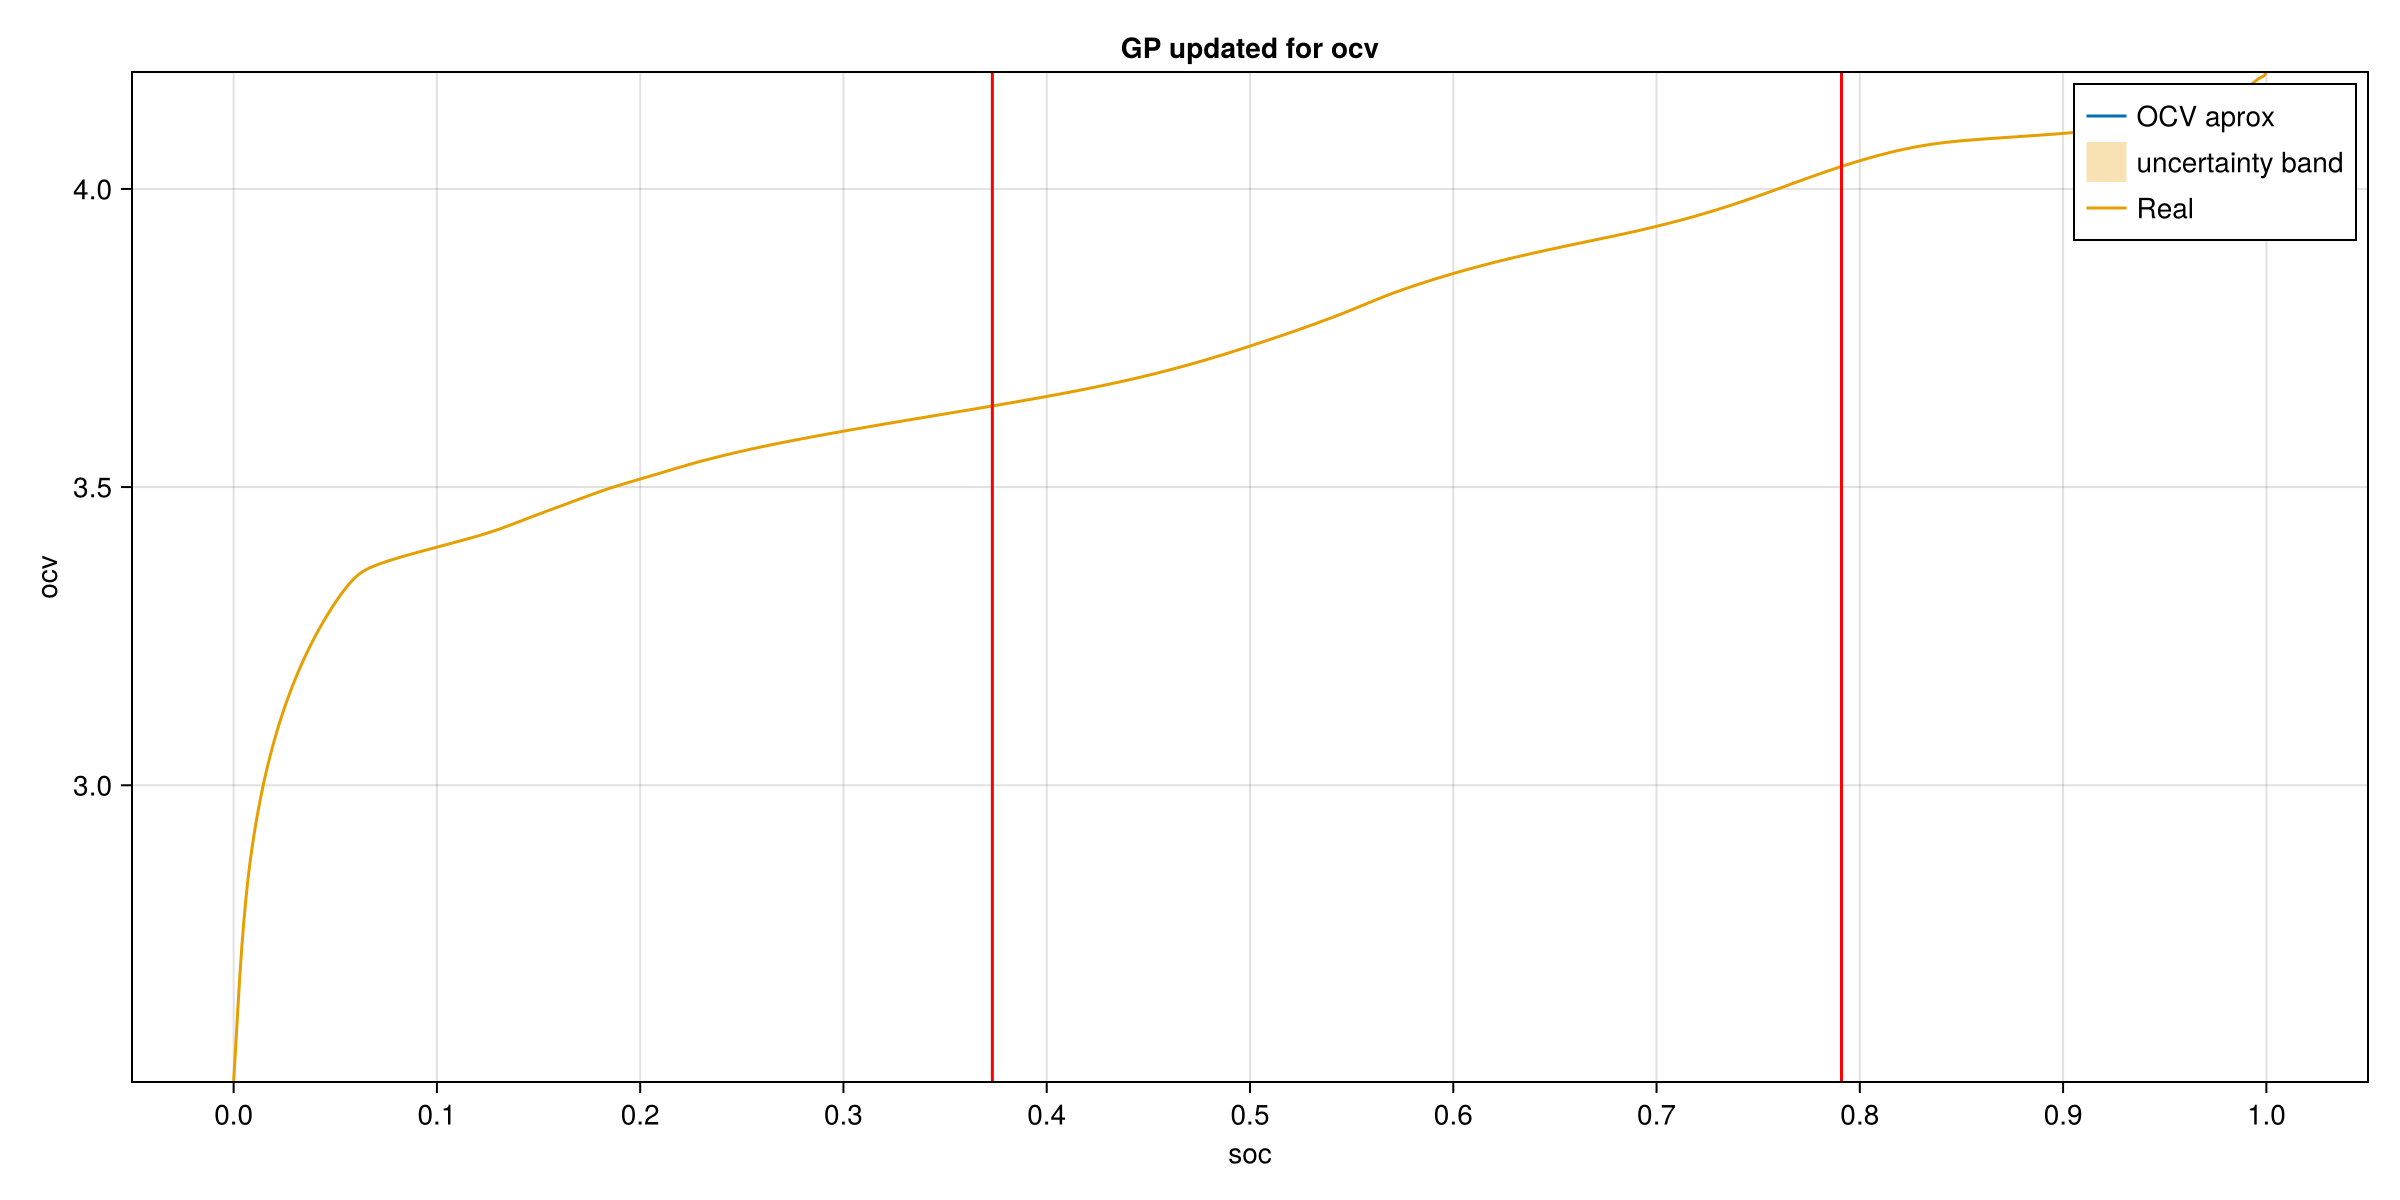

CairoMakie.Screen{IMAGE}


In [7]:
fig = Figure(size = (1200, 600))
ax1 = Axis(fig[1, 1], title="GP updated for ocv", xlabel="soc", ylabel="ocv", xticks=limit_predict[1]:0.1:limit_predict[2])

lines!(ax1, X_predict_soc, μ, label="OCV aprox")
band!(ax1, X_predict_soc, μ - 2σ, μ + 2σ; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))

lines!(ax1,focv.t,focv.u,label="Real")
ylims!(ax1, minimum(focv.u),  maximum(focv.u))
vlines!(ax1, [minimum(X_soc), maximum(X_soc)], color = :red)

#ax2 = Axis(fig[2, 1], title="Error evolution", xlabel="t", ylabel="mse_error")

#lines!(ax2, errors_test, label="Test error")
#lines!(ax2, errors_train, label="Training error")

#save("pictures/synthetic_l$(l_ocv)_sigma$(σ_ocv)_noise$(σ_f1)_n_basis_$(n_basis)_batch_size$(batch_size)_non_hyp.png", fig)
axislegend(ax1)
#axislegend(ax2)
display(fig)

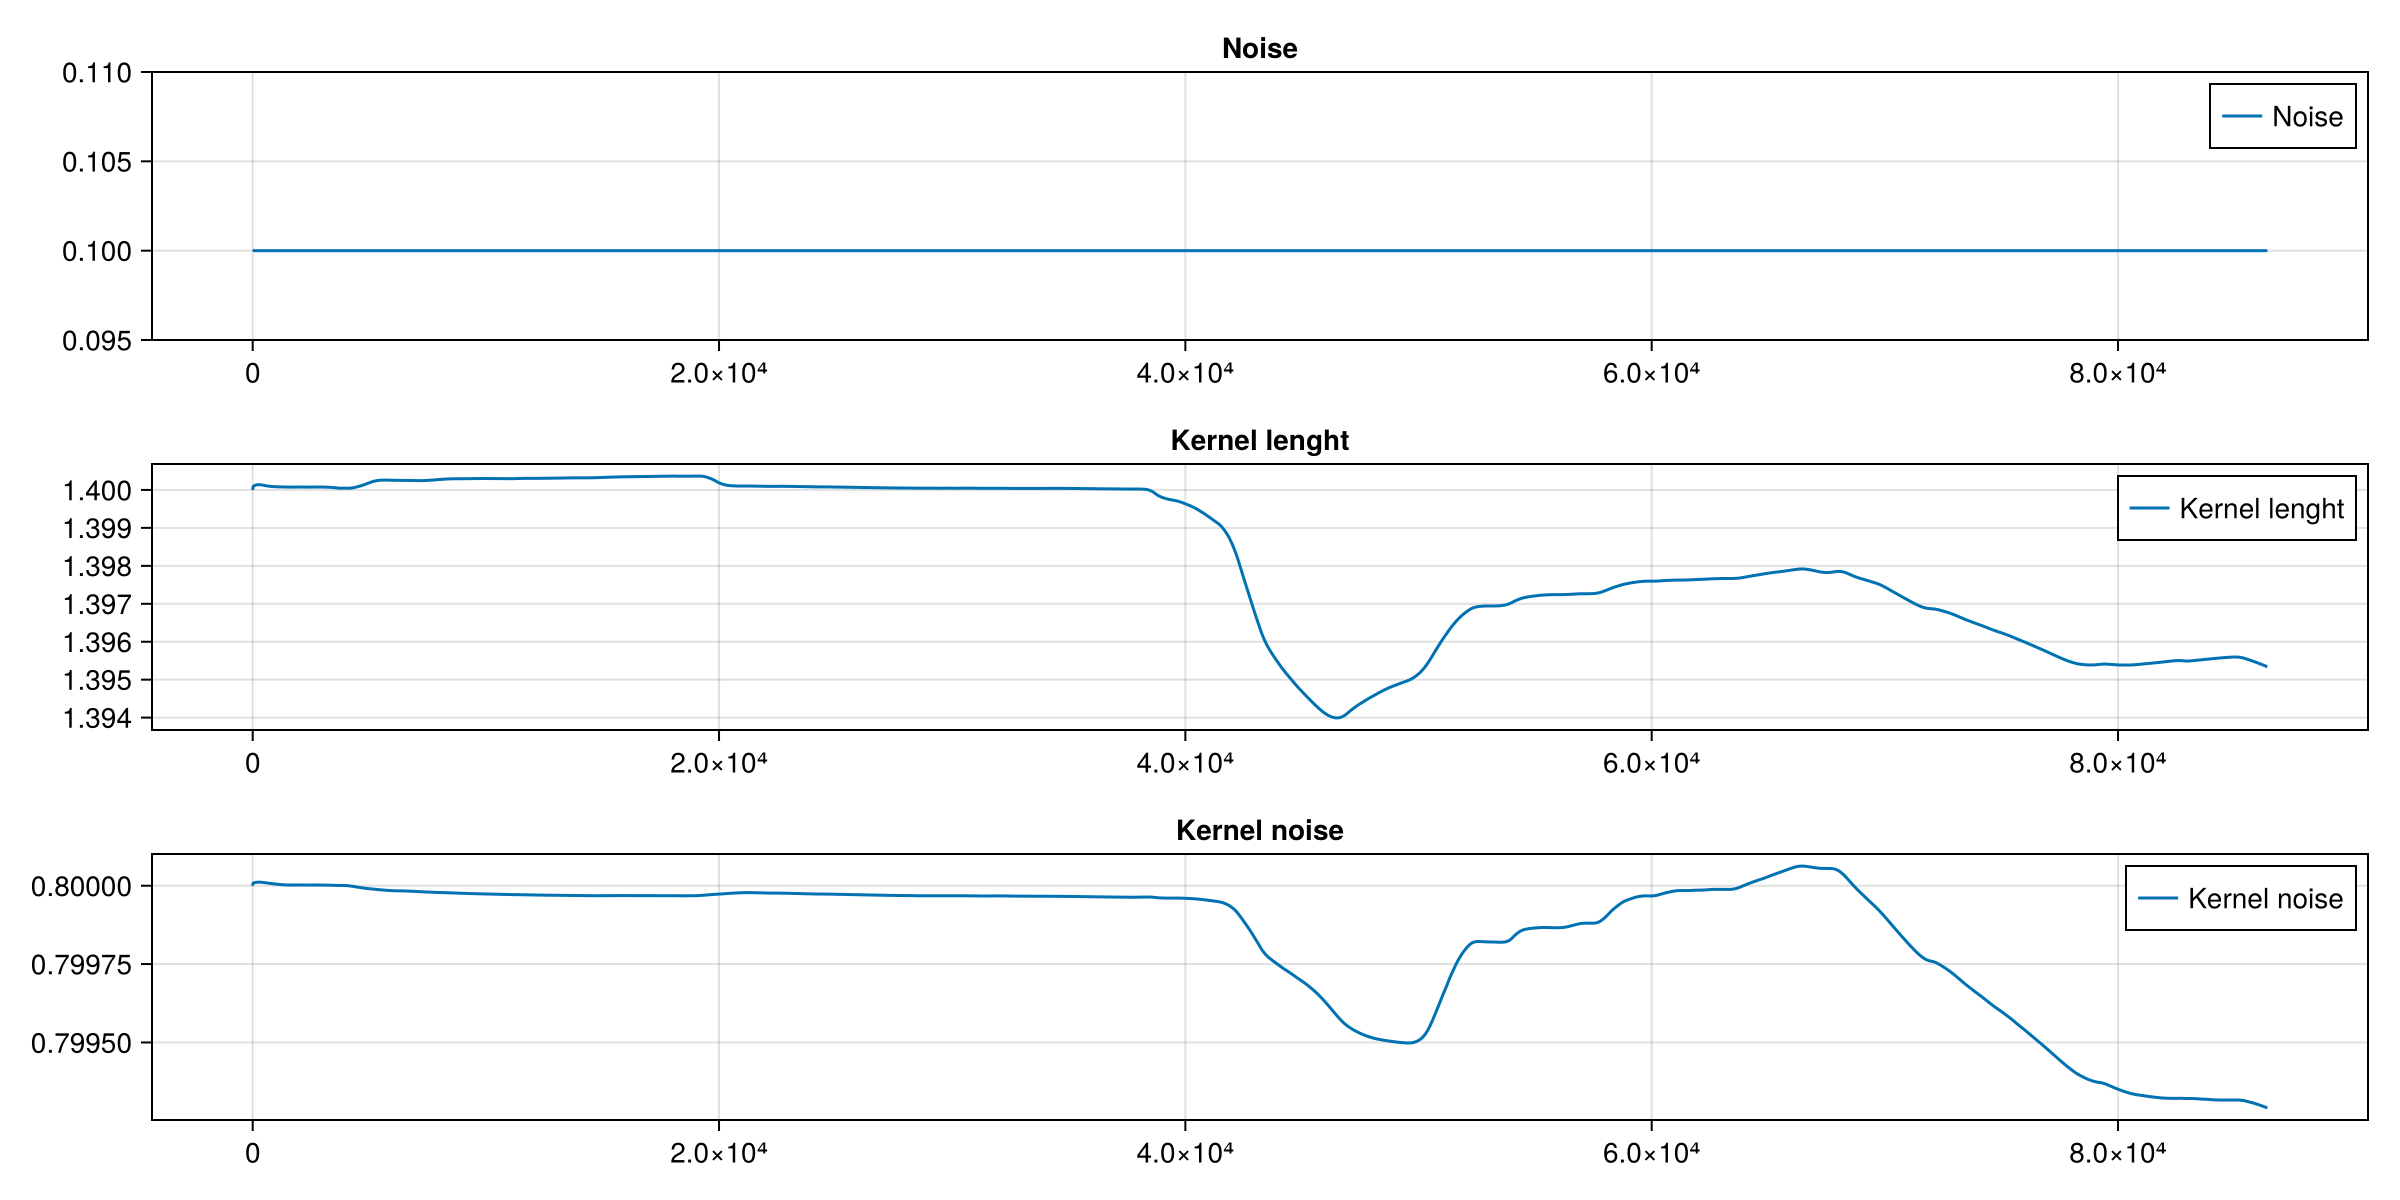

CairoMakie.Screen{IMAGE}


In [43]:
##  function
fig = Figure(size = (1200, 600))
ax1 = Axis(fig[1, 1], title="Noise")
ax2 = Axis(fig[2, 1], title="Kernel lenght")
ax3 = Axis(fig[3, 1], title="Kernel noise")
lines!(ax1, param_evo.σ, label="Noise")
ylims!(ax1, 0.095,0.11)
lines!(ax2, 1 ./param_evo.l, label="Kernel lenght")
lines!(ax3, param_evo.σ_k, label="Kernel noise")
axislegend(ax1)
axislegend(ax2)
axislegend(ax3)

save("pictures/param_evo_l$(l_ocv)_sigma$(σ_ocv)_noise$(σ_f1)_n_basis_$(n_basis)_batch_size$(batch_size)_hyp.png", fig)
display(fig)

In [12]:
fig = Figure(size = (1200, 600))
ax1 = Axis(fig[1, 1], title="GP updated for ocv", xlabel="soc", ylabel="ocv", xticks=limit_predict[1]:0.1:limit_predict[2])

# Static elements
lines!(ax1, focv.t, focv.u, label="Real", color=:black)
vlines!(ax1, [minimum(X_soc), maximum(X_soc)], color = :red)
ylims!(ax1, minimum(focv.u), maximum(focv.u))
ax1.title = "GP updated for ocv"
axislegend(ax1)

# Dynamic elements initialized with first frame
gp_line = lines!(ax1, X_predict_soc, animation.μ[1], label="OCV approx", color=:blue)

band_plot = band!(ax1, X_predict_soc, animation.μ[1] - 2*animation.σ[1], animation.μ[1] + 2*animation.σ[1]; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))
# Animate and save
record(fig, "pictures/animations/synthetic_l$(l_ocv)_sigma$(σ_ocv)_noise$(σ_f1)_n_basis_$(n_basis)_batch_size$(batch_size)_with_hyp.mp4", 1:length(animation.μ); framerate=15) do i
    ax1.title = "GP updated for ocv — Frame $(i*ani_step) / $(N_points)"
    gp_line[2] = animation.μ[i]
    band_plot[2] = animation.μ[i] .- 2*animation.σ[i]
    band_plot[3] = animation.μ[i] .+ 2*animation.σ[i]
end

BoundsError: BoundsError: attempt to access 0-element Vector{Vector{Float64}} at index [1]